# 01 Teste de Ambiente 

Notebook inicial do TCC 
Objetivo: verificar instalação e rodar o primeiro circuito quântico

## Bibliotecas utilizadas
- PennyLane: simulação quântica
- PySCF: química quântica clássica (referência)
- NumPy / Matplotlib: computação numérica e visualização

In [6]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf
import numpy as numpy_original

print('PennyLane:', qml.__version__)
print('PySCF:    ', __import__('pyscf').__version__)
print('NumPy:    ', numpy_original.__version__)

PennyLane: 0.44.1
PySCF:     2.13.0
NumPy:     2.4.4


## 1. Molécula com PySCF

Calculamos a energia do estado fundamental do H₂  
usando Hartree-Fock (RHF) com base STO-3G.  

In [2]:
# Define a molécula
mol = gto.Mole()
mol.atom = '''
    H 0.0 0.0 0.0
    H 0.0 0.0 0.74
'''
mol.basis = 'sto-3g'
mol.unit = 'Angstrom'
mol.build()

# Hartree-Fock
mf = scf.RHF(mol)
energia_hf = mf.kernel()

print(f'\nEnergia HF do H2:  {energia_hf:.6f} Hartree')
print(f'Referência esperada: -1.117349 Hartree')
erro = abs(energia_hf - (-1.117349))
print(f'Erro:                {erro:.2e} Hartree')

converged SCF energy = -1.11675930739643

Energia HF do H2:  -1.116759 Hartree
Referência esperada: -1.117349 Hartree
Erro:                5.90e-04 Hartree


## 2. Circuito Quântico com PennyLane

Circuito variacional simples com 2 qubits:
- Duas rotações RY parametrizadas
- Uma porta CNOT para emaranhamento
- Otimização por gradiente descendente

In [3]:
# Dispositivo simulado
dev = qml.device('default.qubit', wires=2)

# Circuito parametrizado
@qml.qnode(dev)
def circuito(params):
    qml.RY(params[0], wires=0)   # rotação qubit 0
    qml.RY(params[1], wires=1)   # rotação qubit 1
    qml.CNOT(wires=[0, 1])       # emaranhamento
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))

# Visualiza o circuito
params_iniciais = np.array([0.5, 0.5], requires_grad=True)
print(qml.draw(circuito)(params_iniciais))

0: ──RY(0.50)─╭●─┤ ╭<Z@Z>
1: ──RY(0.50)─╰X─┤ ╰<Z@Z>


In [4]:
# Otimizador e parâmetros iniciais
params = np.array([0.5, 0.5], requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.1)

# Loop de otimização — guarda histórico para plotar
historico = []

for i in range(50):
    params, custo = opt.step_and_cost(circuito, params)
    historico.append(float(custo))

print(f'Energia inicial: {historico[0]:.6f}')
print(f'Energia final:   {historico[-1]:.6f}')
print(f'Esperado:        -1.000000')

Energia inicial: 0.877583
Energia final:   -0.998642
Esperado:        -1.000000


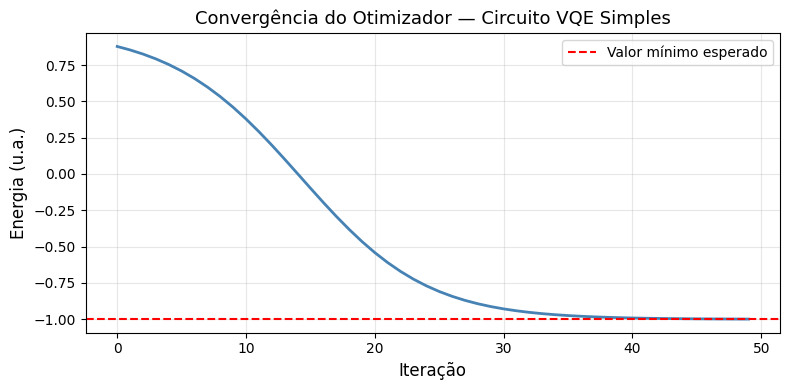

In [5]:
#Gráfico de convergência
plt.figure(figsize=(8, 4))
plt.plot(historico, color='steelblue', linewidth=2)
plt.axhline(y=-1.0, color='red', linestyle='--', 
            linewidth=1.5, label='Valor mínimo esperado')
plt.xlabel('Iteração', fontsize=12)
plt.ylabel('Energia (u.a.)', fontsize=12)
plt.title('Convergência do Otimizador — Circuito VQE Simples', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('convergencia_teste.png', dpi=150)
plt.show()

## Conclusões

- Ambiente instalado e funcionando corretamente
- PySCF calculou energia HF do H₂ dentro do esperado
- PennyLane criou e otimizou o circuito variacional com sucesso
- O otimizador convergiu para o valor mínimo em ~30 iterações